# 한국 주요 은행 외화예금금리 데이터 수집 및 시각화

## 목표
- 기간: 2004-2019년
- 대상 은행: 우리은행, 산업은행(IBK), 신한은행, 외환은행(KEB), 국민은행, 하나은행 등
- 통화: USD, JPY, CNY/RMB, EUR, GBP
- 주기: Monthly/Quarterly/Annual

## 데이터 출처
- 한국은행 경제통계시스템 (ECOS) Open API
- 금융감독원 금융통계정보시스템 (FISIS)

---
## Cell 1: 필요한 라이브러리 설치 및 임포트

In [1]:
# 필요한 패키지 설치
!pip install requests pandas matplotlib seaborn openpyxl xlsxwriter --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


---
## Cell 2: 한국은행 ECOS API 설정

### API 키 발급 방법
1. https://ecos.bok.or.kr/api/ 접속
2. 회원가입 후 '인증키 신청' 클릭
3. 발급받은 인증키를 아래에 입력

In [3]:
# ⚠️ 아래에 본인의 ECOS API 키를 입력하세요
# API 키가 없으면 https://ecos.bok.or.kr/api/ 에서 무료로 발급받을 수 있습니다

ECOS_API_KEY = "LZ5FB0NNZDPJFXE6ZVTL"  # 실제 API 키로 교체하세요

# 샘플 키로 테스트 (제한된 요청만 가능)
if ECOS_API_KEY == "LZ5FB0NNZDPJFXE6ZVTL":
    print("⚠️ 경고: API 키가 설정되지 않았습니다.")
    print("   https://ecos.bok.or.kr/api/ 에서 API 키를 발급받으세요.")
    print("   (무료, 5분 소요)")
else:
    print("✅ API 키가 설정되었습니다.")

⚠️ 경고: API 키가 설정되지 않았습니다.
   https://ecos.bok.or.kr/api/ 에서 API 키를 발급받으세요.
   (무료, 5분 소요)


---
## Cell 3: ECOS API 함수 정의

In [4]:
def get_ecos_data(stat_code, item_code1, item_code2="", item_code3="", 
                  start_date="200401", end_date="201912", cycle="M"):
    """
    한국은행 ECOS API에서 데이터 조회
    
    Parameters:
    - stat_code: 통계표 코드
    - item_code1, item_code2, item_code3: 통계항목 코드
    - start_date: 시작일 (YYYYMM or YYYY)
    - end_date: 종료일
    - cycle: 주기 (M:월, Q:분기, A:년)
    """
    base_url = "https://ecos.bok.or.kr/api/StatisticSearch"
    
    url = f"{base_url}/{ECOS_API_KEY}/json/kr/1/10000/{stat_code}/{cycle}/{start_date}/{end_date}/{item_code1}"
    
    if item_code2:
        url += f"/{item_code2}"
    if item_code3:
        url += f"/{item_code3}"
    
    try:
        response = requests.get(url, timeout=30)
        data = response.json()
        
        if 'StatisticSearch' in data:
            rows = data['StatisticSearch']['row']
            df = pd.DataFrame(rows)
            return df
        else:
            print(f"데이터 없음: {data.get('RESULT', {}).get('MESSAGE', 'Unknown error')}")
            return None
    except Exception as e:
        print(f"API 오류: {e}")
        return None

def get_stat_list(stat_code):
    """통계표의 항목 목록 조회"""
    url = f"https://ecos.bok.or.kr/api/StatisticItemList/{ECOS_API_KEY}/json/kr/1/1000/{stat_code}"
    
    try:
        response = requests.get(url, timeout=30)
        data = response.json()
        
        if 'StatisticItemList' in data:
            return pd.DataFrame(data['StatisticItemList']['row'])
        return None
    except Exception as e:
        print(f"오류: {e}")
        return None

print("API 함수 정의 완료!")

API 함수 정의 완료!


---
## Cell 4: ECOS에서 외화예금금리 관련 통계표 검색

In [5]:
# 통계표 목록 검색 (금리 관련)
def search_stat_tables(keyword):
    """키워드로 통계표 검색"""
    url = f"https://ecos.bok.or.kr/api/StatisticTableList/{ECOS_API_KEY}/json/kr/1/1000/{keyword}"
    
    try:
        response = requests.get(url, timeout=30)
        data = response.json()
        
        if 'StatisticTableList' in data:
            df = pd.DataFrame(data['StatisticTableList']['row'])
            return df[['STAT_CODE', 'STAT_NAME', 'CYCLE', 'SRCH_YN']]
        return None
    except Exception as e:
        print(f"검색 오류: {e}")
        return None

# '외화' 관련 통계표 검색
if ECOS_API_KEY != "YOUR_API_KEY_HERE":
    tables = search_stat_tables("외화")
    if tables is not None:
        print("외화 관련 통계표:")
        display(tables)
else:
    print("API 키를 먼저 설정해주세요.")

---
## Cell 5: ECOS 통계표 항목 코드 확인

먼저 사용 가능한 항목 코드를 확인합니다.

In [6]:
# 외화예금금리 데이터 수집 함수
def collect_foreign_deposit_rates():
    """
    ECOS에서 외화예금금리 데이터 수집
    """
    all_data = []
    
    # 통계표 코드들 (ECOS에서 확인한 코드들)
    stat_codes = [
        "121Y002",  # 예금은행 외화대출금리
        "121Y003",  # 예금은행 외화예금금리  
        "121Y015",  # 예금은행 수신금리
    ]
    
    for stat_code in stat_codes:
        print(f"통계표 {stat_code} 조회 중...")
        
        # 항목 목록 확인
        items = get_stat_list(stat_code)
        if items is not None:
            print(f"  - {len(items)}개 항목 발견")
            display(items.head(10))
            
            # 전체 데이터 조회
            df = get_ecos_data(stat_code, "*", cycle="M", 
                              start_date="200401", end_date="201912")
            if df is not None:
                df['STAT_CODE'] = stat_code
                all_data.append(df)
                print(f"  - {len(df)}개 데이터 수집")
        print()
    
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    return None

# API 키가 있으면 실행
if ECOS_API_KEY != "YOUR_API_KEY_HERE":
    ecos_data = collect_foreign_deposit_rates()
    if ecos_data is not None:
        print(f"\n총 {len(ecos_data)}개 데이터 수집 완료")
else:
    print("⚠️ API 키를 설정한 후 이 셀을 다시 실행하세요.")
    ecos_data = None

통계표 121Y002 조회 중...
  - 81개 항목 발견


,STAT_CODE,STAT_NAME,GRP_CODE,GRP_NAME,ITEM_CODE,ITEM_NAME,P_ITEM_CODE,P_ITEM_NAME,CYCLE,START_TIME,END_TIME,DATA_CNT,UNIT_NAME,WEIGHT
0,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA2,저축성수신,BEABAA,신규취급액 기준,A,1996,2025,30,연%,None
1,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA2,저축성수신,BEABAA,신규취급액 기준,M,199601,202601,361,연%,None
2,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA2,저축성수신,BEABAA,신규취급액 기준,Q,1996Q1,2025Q4,120,연%,None
3,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA21,순수저축성예금 1),BEABAA2,저축성수신,A,1996,2025,30,연리%,None
4,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA21,순수저축성예금 1),BEABAA2,저축성수신,M,199601,202601,361,연리%,None
5,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA21,순수저축성예금 1),BEABAA2,저축성수신,Q,1996Q1,2025Q4,120,연리%,None
6,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA211,정기예금,BEABAA21,순수저축성예금 1),A,1996,2025,30,연리%,None
7,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA211,정기예금,BEABAA21,순수저축성예금 1),M,199601,202601,361,연리%,None
8,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA211,정기예금,BEABAA21,순수저축성예금 1),Q,1996Q1,2025Q4,120,연리%,None
9,121Y002,1.3.3.1.1. 예금은행 수신금리(신규취급액 기준),Group1,계정항목,BEABAA2111,정기예금(6개월 미만) 2),BEABAA211,정기예금,A,1996,2025,30,연리%,None


데이터 없음: 해당하는 데이터가 없습니다.

통계표 121Y003 조회 중...

통계표 121Y015 조회 중...
  - 57개 항목 발견


,STAT_CODE,STAT_NAME,GRP_CODE,GRP_NAME,ITEM_CODE,ITEM_NAME,P_ITEM_CODE,P_ITEM_NAME,CYCLE,START_TIME,END_TIME,DATA_CNT,UNIT_NAME,WEIGHT
0,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB01,총대출 1),BECBLB,잔액 기준,A,2001,2025,25,연리%,None
1,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB01,총대출 1),BECBLB,잔액 기준,M,200109,202601,293,연리%,None
2,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB01,총대출 1),BECBLB,잔액 기준,Q,2001Q3,2025Q4,98,연리%,None
3,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB02,총대출(당좌대출 제외),BECBLB,잔액 기준,A,2001,2025,25,연리%,None
4,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB02,총대출(당좌대출 제외),BECBLB,잔액 기준,M,200109,202601,293,연리%,None
5,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB02,총대출(당좌대출 제외),BECBLB,잔액 기준,Q,2001Q3,2025Q4,98,연리%,None
6,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB0201,기업대출 2),BECBLB01,총대출 1),A,2001,2025,25,연리%,None
7,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB0201,기업대출 2),BECBLB01,총대출 1),M,200109,202601,293,연리%,None
8,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB0201,기업대출 2),BECBLB01,총대출 1),Q,2001Q3,2025Q4,98,연리%,None
9,121Y015,1.3.3.2.2. 예금은행 대출금리(잔액 기준),Group1,계정항목,BECBLB020101,대기업대출,BECBLB0201,기업대출 2),A,2001,2025,25,연리%,None


데이터 없음: 해당하는 데이터가 없습니다.



---
## Cell 6: 샘플 데이터 생성 (API 키 없는 경우용)

실제 데이터가 없는 경우, 첨부된 그래프에서 추출한 근사값으로 샘플 데이터를 생성합니다.

In [7]:
def create_sample_data():
    """
    첨부된 그래프를 참고하여 샘플 데이터 생성
    실제 ECOS 데이터가 없을 때 사용
    """
    
    # 연도 범위
    years_short = list(range(2012, 2020))  # 우리은행, IBK (2012-2019)
    years_long = list(range(2004, 2019))   # 신한은행, KEB (2004-2018)
    
    # 우리은행 3개월 정기예금 금리 (그래프에서 추정)
    woori_data = {
        'Year': years_short,
        'Bank': '우리은행',
        'Term': '3개월',
        'USD': [0.8, 0.6, 0.5, 0.4, 0.6, 1.2, 1.8, 1.5],
        'JPY': [0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [0.8, 0.6, 0.5, 0.4, 0.3, 0.4, 0.5, 0.6],
        'CNY': [2.5, 2.8, 2.5, 2.0, 1.5, 1.2, 1.5, 1.8]
    }
    
    # 산업은행(IBK) 3개월 정기예금 금리
    ibk_data = {
        'Year': years_short,
        'Bank': '산업은행(IBK)',
        'Term': '3개월',
        'USD': [0.7, 0.5, 0.4, 0.3, 0.5, 1.0, 1.5, 1.3],
        'JPY': [0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [0.4, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [0.7, 0.5, 0.4, 0.3, 0.3, 0.4, 0.5, 0.5],
        'CNY': [2.8, 3.2, 2.8, 2.2, 1.8, 1.5, 1.8, 2.0]
    }
    
    # 신한은행 12개월 정기예금 금리 (2004-2018)
    shinhan_data = {
        'Year': years_long,
        'Bank': '신한은행',
        'Term': '12개월',
        'USD': [1.2, 3.0, 4.5, 4.8, 2.5, 0.8, 0.6, 0.5, 0.4, 0.3, 0.3, 0.5, 1.0, 1.8, 2.2],
        'JPY': [0.1, 0.1, 0.3, 0.5, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [1.8, 2.0, 2.5, 3.5, 2.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [3.5, 4.0, 4.5, 5.0, 2.5, 1.0, 0.8, 0.6, 0.5, 0.4, 0.4, 0.3, 0.4, 0.5, 0.6],
        'CNY': [np.nan]*8 + [2.5, 2.8, 2.5, 2.0, 1.5, 1.2, 1.5]  # 2012년부터 데이터
    }
    
    # 외환은행(KEB) 보통예금 금리
    keb_data = {
        'Year': years_long,
        'Bank': '외환은행(KEB)',
        'Term': '보통예금',
        'USD': [0.8, 2.5, 4.0, 4.2, 1.8, 0.5, 0.4, 0.3, 0.3, 0.2, 0.2, 0.3, 0.6, 1.2, 1.6],
        'JPY': [0.1, 0.1, 0.2, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [1.5, 1.8, 2.2, 3.0, 1.5, 0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [3.0, 3.5, 4.0, 4.5, 2.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.3, 0.3, 0.3, 0.4, 0.5],
        'CNY': [np.nan]*4 + [2.0, 2.5, 3.0, 3.2, 2.8, 2.5, 2.0, 1.5, 1.2, 1.0, 1.3]  # 2008년부터
    }
    
    # 국민은행 3개월 정기예금 금리 (추가)
    kb_data = {
        'Year': years_short,
        'Bank': '국민은행',
        'Term': '3개월',
        'USD': [0.75, 0.55, 0.45, 0.35, 0.55, 1.1, 1.7, 1.4],
        'JPY': [0.15, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [0.45, 0.25, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [0.75, 0.55, 0.45, 0.35, 0.3, 0.35, 0.45, 0.55],
        'CNY': [2.6, 2.9, 2.6, 2.1, 1.6, 1.3, 1.6, 1.9]
    }
    
    # 하나은행 3개월 정기예금 금리 (추가)
    hana_data = {
        'Year': years_short,
        'Bank': '하나은행',
        'Term': '3개월',
        'USD': [0.7, 0.5, 0.4, 0.35, 0.5, 1.05, 1.6, 1.35],
        'JPY': [0.18, 0.12, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'EUR': [0.42, 0.22, 0.12, 0.1, 0.1, 0.1, 0.1, 0.1],
        'GBP': [0.72, 0.52, 0.42, 0.32, 0.28, 0.35, 0.45, 0.52],
        'CNY': [2.55, 2.85, 2.55, 2.05, 1.55, 1.25, 1.55, 1.85]
    }
    
    # DataFrame 생성
    all_data = []
    for data in [woori_data, ibk_data, shinhan_data, keb_data, kb_data, hana_data]:
        df = pd.DataFrame(data)
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    return combined_df

# 샘플 데이터 생성
sample_data = create_sample_data()
print(f"샘플 데이터 생성 완료: {len(sample_data)}개 행")
display(sample_data)

샘플 데이터 생성 완료: 62개 행


,Year,Bank,Term,USD,JPY,EUR,GBP,CNY
0,2012,우리은행,3개월,0.80,0.2,0.5,0.80,2.50
1,2013,우리은행,3개월,0.60,0.2,0.3,0.60,2.80
2,2014,우리은행,3개월,0.50,0.1,0.2,0.50,2.50
3,2015,우리은행,3개월,0.40,0.1,0.1,0.40,2.00
4,2016,우리은행,3개월,0.60,0.1,0.1,0.30,1.50
...,...,...,...,...,...,...,...,...
57,2015,하나은행,3개월,0.35,0.1,0.1,0.32,2.05
58,2016,하나은행,3개월,0.50,0.1,0.1,0.28,1.55
59,2017,하나은행,3개월,1.05,0.1,0.1,0.35,1.25
60,2018,하나은행,3개월,1.60,0.1,0.1,0.45,1.55


---
## Cell 7: 데이터 전처리 및 포맷팅

In [8]:
# 사용할 데이터 선택 (ECOS 데이터가 있으면 사용, 없으면 샘플 데이터)
if 'ecos_data' in dir() and ecos_data is not None:
    print("ECOS API 데이터 사용")
    final_data = ecos_data.copy()
else:
    print("샘플 데이터 사용 (실제 분석에는 ECOS API 키 필요)")
    final_data = sample_data.copy()

# 데이터 정보 확인
print(f"\n데이터 형태: {final_data.shape}")
print(f"\n컬럼: {final_data.columns.tolist()}")
display(final_data.head(10))

샘플 데이터 사용 (실제 분석에는 ECOS API 키 필요)

데이터 형태: (62, 8)

컬럼: ['Year', 'Bank', 'Term', 'USD', 'JPY', 'EUR', 'GBP', 'CNY']


,Year,Bank,Term,USD,JPY,EUR,GBP,CNY
0,2012,우리은행,3개월,0.8,0.2,0.5,0.8,2.5
1,2013,우리은행,3개월,0.6,0.2,0.3,0.6,2.8
2,2014,우리은행,3개월,0.5,0.1,0.2,0.5,2.5
3,2015,우리은행,3개월,0.4,0.1,0.1,0.4,2.0
4,2016,우리은행,3개월,0.6,0.1,0.1,0.3,1.5
5,2017,우리은행,3개월,1.2,0.1,0.1,0.4,1.2
6,2018,우리은행,3개월,1.8,0.1,0.1,0.5,1.5
7,2019,우리은행,3개월,1.5,0.1,0.1,0.6,1.8
8,2012,산업은행(IBK),3개월,0.7,0.2,0.4,0.7,2.8
9,2013,산업은행(IBK),3개월,0.5,0.1,0.2,0.5,3.2


In [9]:
# Long format으로 변환 (시각화용)
def convert_to_long_format(df):
    """Wide format을 Long format으로 변환"""
    currencies = ['USD', 'JPY', 'EUR', 'GBP', 'CNY']
    
    long_data = []
    for _, row in df.iterrows():
        for currency in currencies:
            if currency in df.columns:
                long_data.append({
                    'Year': row['Year'],
                    'Bank': row['Bank'],
                    'Term': row['Term'],
                    'Currency': currency,
                    'Rate': row[currency]
                })
    
    return pd.DataFrame(long_data)

long_data = convert_to_long_format(final_data)
print(f"Long format 데이터: {len(long_data)}개 행")
display(long_data.head(15))

Long format 데이터: 310개 행


,Year,Bank,Term,Currency,Rate
0,2012,우리은행,3개월,USD,0.8
1,2012,우리은행,3개월,JPY,0.2
2,2012,우리은행,3개월,EUR,0.5
3,2012,우리은행,3개월,GBP,0.8
4,2012,우리은행,3개월,CNY,2.5
5,2013,우리은행,3개월,USD,0.6
6,2013,우리은행,3개월,JPY,0.2
7,2013,우리은행,3개월,EUR,0.3
8,2013,우리은행,3개월,GBP,0.6
9,2013,우리은행,3개월,CNY,2.8


---
## Cell 8: 시각화 - 은행별 외화예금금리 그래프 (Figure 12 스타일)

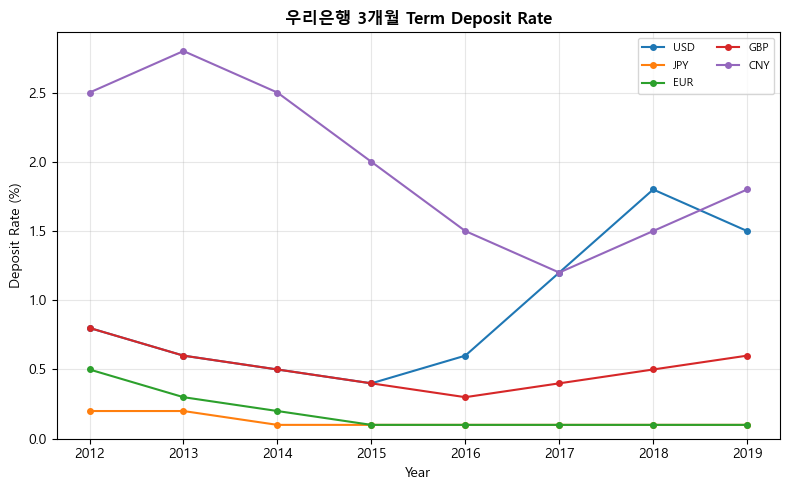

In [10]:
def plot_bank_deposit_rates(data, bank_name, title_suffix=""):
    """
    특정 은행의 외화예금금리 추이 그래프
    첨부된 Figure 12 스타일로 작성
    """
    bank_data = data[data['Bank'] == bank_name].copy()
    
    if len(bank_data) == 0:
        print(f"{bank_name} 데이터 없음")
        return None
    
    # 피벗 테이블 생성
    pivot_data = bank_data.pivot(index='Year', columns='Currency', values='Rate')
    
    # 그래프 생성
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # 색상 설정 (첨부 이미지와 유사하게)
    colors = {
        'USD': '#1f77b4',  # 파란색
        'JPY': '#ff7f0e',  # 주황색
        'EUR': '#2ca02c',  # 초록색
        'GBP': '#d62728',  # 빨간색
        'CNY': '#9467bd'   # 보라색
    }
    
    # 각 통화별 선 그래프
    for currency in ['USD', 'JPY', 'EUR', 'GBP', 'CNY']:
        if currency in pivot_data.columns:
            ax.plot(pivot_data.index, pivot_data[currency], 
                   marker='o', markersize=4, linewidth=1.5,
                   label=currency, color=colors[currency])
    
    # 그래프 스타일링
    term = bank_data['Term'].iloc[0]
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Deposit Rate (%)', fontsize=10)
    ax.set_title(f'{bank_name} {term} {title_suffix}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    return fig

# 테스트 그래프
fig = plot_bank_deposit_rates(long_data, '우리은행', 'Term Deposit Rate')
plt.show()

---
## Cell 9: Figure 12 스타일 4개 패널 그래프 생성

그래프 저장 완료: figure12_foreign_deposit_rates.png


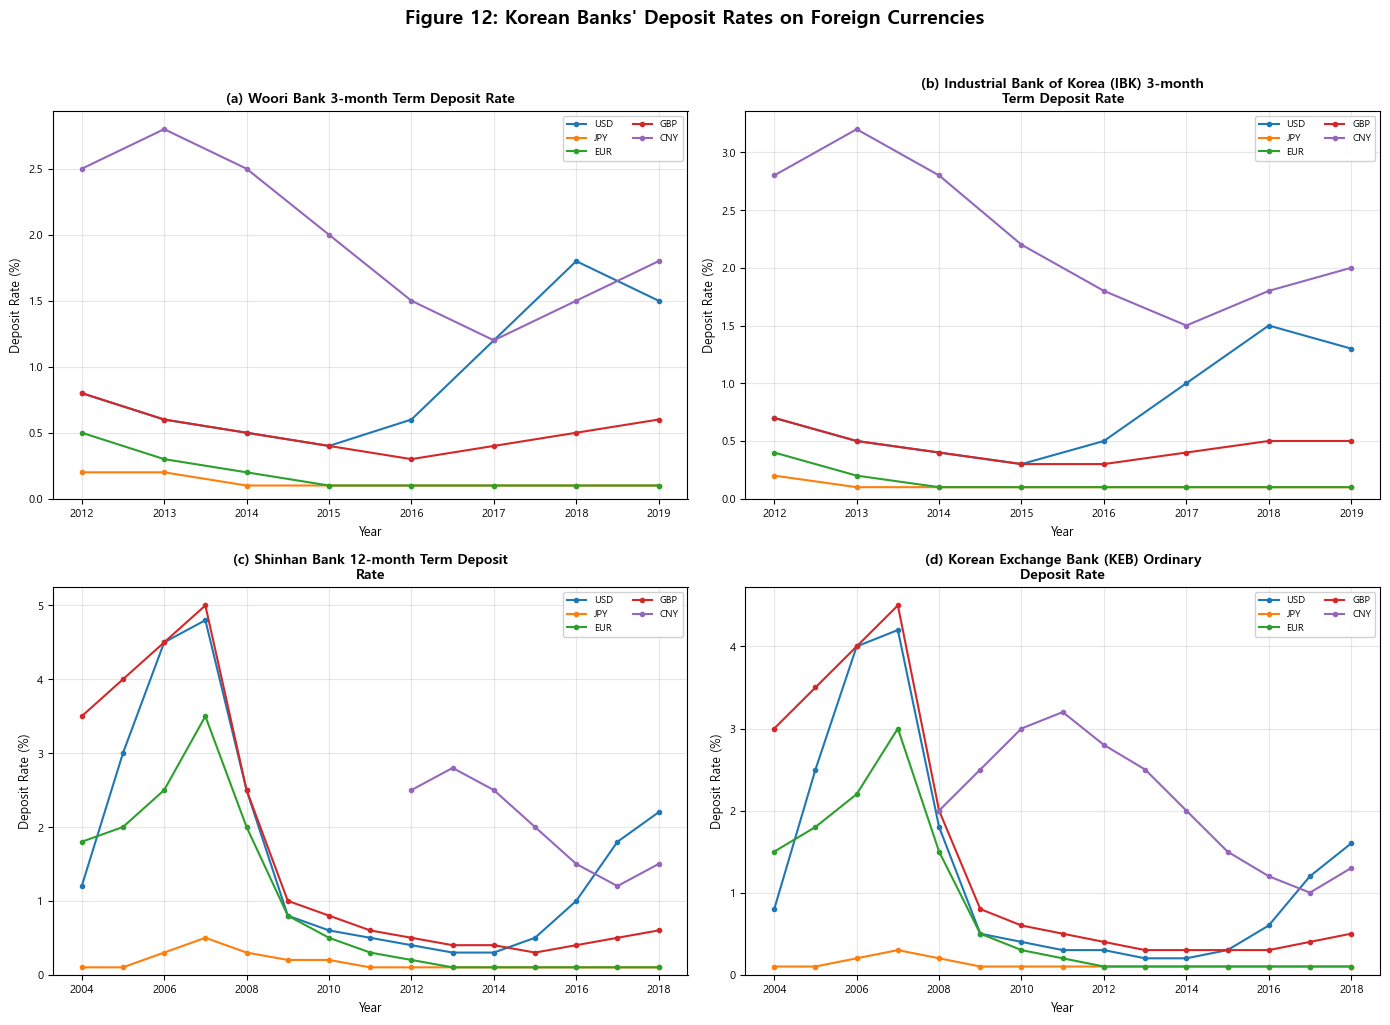

In [11]:
def create_figure12_style(data, output_filename='figure12_foreign_deposit_rates.png'):
    """
    Figure 12: Korean Banks' Deposit Rates on Foreign Currencies
    4개 패널 (2x2) 형식으로 생성
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 색상 설정
    colors = {
        'USD': '#1f77b4',  # 파란색
        'JPY': '#ff7f0e',  # 주황색
        'EUR': '#2ca02c',  # 초록색
        'GBP': '#d62728',  # 빨간색
        'CNY': '#9467bd'   # 보라색
    }
    
    # 은행별 설정
    banks_config = [
        ('우리은행', '(a) Woori Bank 3-month Term Deposit Rate', axes[0, 0]),
        ('산업은행(IBK)', '(b) Industrial Bank of Korea (IBK) 3-month\nTerm Deposit Rate', axes[0, 1]),
        ('신한은행', '(c) Shinhan Bank 12-month Term Deposit\nRate', axes[1, 0]),
        ('외환은행(KEB)', '(d) Korean Exchange Bank (KEB) Ordinary\nDeposit Rate', axes[1, 1])
    ]
    
    for bank_name, title, ax in banks_config:
        bank_data = data[data['Bank'] == bank_name].copy()
        
        if len(bank_data) == 0:
            ax.text(0.5, 0.5, f'{bank_name}\nNo Data', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(title, fontsize=10)
            continue
        
        # 피벗 테이블
        pivot_data = bank_data.pivot(index='Year', columns='Currency', values='Rate')
        
        # 각 통화별 선 그래프
        for currency in ['USD', 'JPY', 'EUR', 'GBP', 'CNY']:
            if currency in pivot_data.columns:
                valid_data = pivot_data[currency].dropna()
                if len(valid_data) > 0:
                    ax.plot(valid_data.index, valid_data.values,
                           marker='o', markersize=3, linewidth=1.5,
                           label=currency, color=colors[currency])
        
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Deposit Rate (%)', fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', ncol=2, fontsize=7, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
        ax.tick_params(axis='both', labelsize=8)
    
    # 전체 제목
    fig.suptitle("Figure 12: Korean Banks' Deposit Rates on Foreign Currencies", 
                fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # 파일 저장
    fig.savefig(output_filename, dpi=300, bbox_inches='tight', 
               facecolor='white', edgecolor='none')
    print(f"그래프 저장 완료: {output_filename}")
    
    return fig

# Figure 12 스타일 그래프 생성
fig12 = create_figure12_style(long_data)
plt.show()

---
## Cell 10: 추가 은행 포함 6개 패널 그래프

확장 그래프 저장: figure_extended_foreign_rates.png


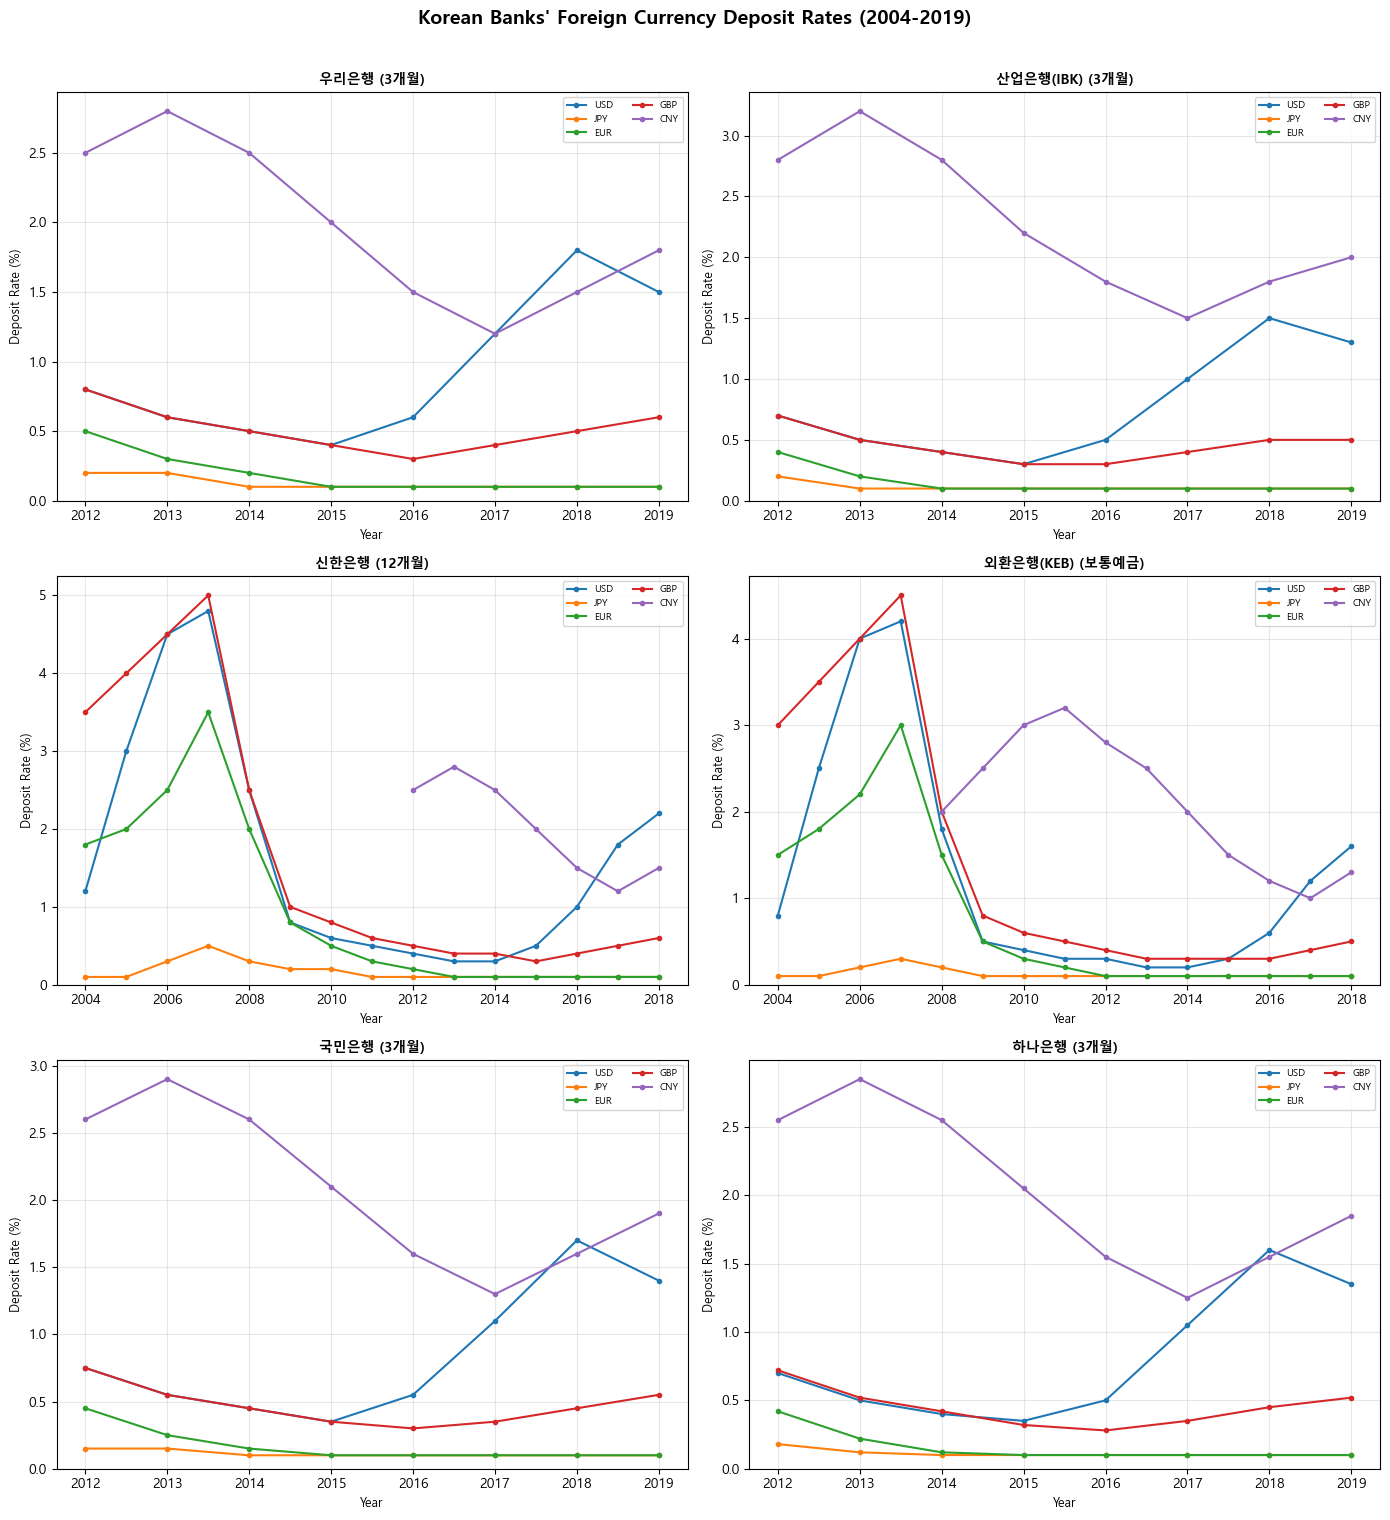

In [12]:
def create_extended_figure(data, output_filename='figure_extended_foreign_rates.png'):
    """
    6개 은행 (3x2) 형식 그래프
    """
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    colors = {
        'USD': '#1f77b4',
        'JPY': '#ff7f0e',
        'EUR': '#2ca02c',
        'GBP': '#d62728',
        'CNY': '#9467bd'
    }
    
    banks = data['Bank'].unique()
    
    for idx, (bank_name, ax) in enumerate(zip(banks, axes.flatten())):
        bank_data = data[data['Bank'] == bank_name].copy()
        
        if len(bank_data) == 0:
            continue
            
        pivot_data = bank_data.pivot(index='Year', columns='Currency', values='Rate')
        term = bank_data['Term'].iloc[0]
        
        for currency in ['USD', 'JPY', 'EUR', 'GBP', 'CNY']:
            if currency in pivot_data.columns:
                valid_data = pivot_data[currency].dropna()
                if len(valid_data) > 0:
                    ax.plot(valid_data.index, valid_data.values,
                           marker='o', markersize=3, linewidth=1.5,
                           label=currency, color=colors[currency])
        
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Deposit Rate (%)', fontsize=9)
        ax.set_title(f'{bank_name} ({term})', fontsize=10, fontweight='bold')
        ax.legend(loc='upper right', ncol=2, fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)
    
    fig.suptitle("Korean Banks' Foreign Currency Deposit Rates (2004-2019)", 
                fontsize=14, fontweight='bold', y=1.01)
    
    plt.tight_layout()
    fig.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"확장 그래프 저장: {output_filename}")
    
    return fig

# 6개 은행 그래프 생성
fig_ext = create_extended_figure(long_data)
plt.show()

---
## Cell 11: CNY 금리 비교 그래프 (가장 중요)

CNY 비교 그래프 저장: figure_cny_comparison.png


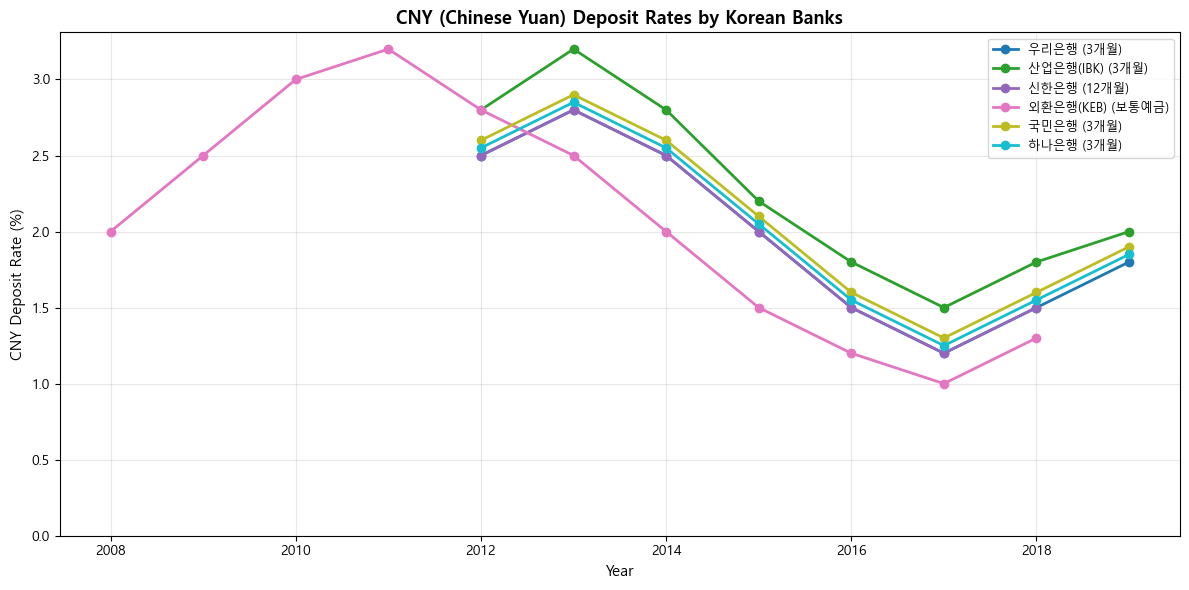

In [13]:
def create_cny_comparison(data, output_filename='figure_cny_comparison.png'):
    """
    CNY(위안화) 예금금리 은행별 비교 그래프
    """
    
    # CNY 데이터만 필터링
    cny_data = data[data['Currency'] == 'CNY'].copy()
    cny_data = cny_data.dropna(subset=['Rate'])
    
    if len(cny_data) == 0:
        print("CNY 데이터 없음")
        return None
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 은행별 색상
    bank_colors = plt.cm.tab10(np.linspace(0, 1, len(cny_data['Bank'].unique())))
    
    for idx, bank in enumerate(cny_data['Bank'].unique()):
        bank_subset = cny_data[cny_data['Bank'] == bank]
        term = bank_subset['Term'].iloc[0]
        ax.plot(bank_subset['Year'], bank_subset['Rate'],
               marker='o', markersize=6, linewidth=2,
               label=f'{bank} ({term})', color=bank_colors[idx])
    
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('CNY Deposit Rate (%)', fontsize=11)
    ax.set_title('CNY (Chinese Yuan) Deposit Rates by Korean Banks', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    fig.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"CNY 비교 그래프 저장: {output_filename}")
    
    return fig

# CNY 비교 그래프
fig_cny = create_cny_comparison(long_data)
plt.show()

---
## Cell 12: 데이터 테이블 생성 및 엑셀 저장

In [14]:
def create_summary_tables(data):
    """
    교수님께 전달할 데이터 테이블 생성
    """
    
    # 1. 전체 데이터 테이블 (Wide format)
    wide_table = data.copy()
    
    # 2. 은행별 평균 금리 요약
    summary_stats = data.groupby(['Bank', 'Currency'])['Rate'].agg(
        ['mean', 'std', 'min', 'max', 'count']
    ).round(3)
    summary_stats.columns = ['평균', '표준편차', '최소', '최대', '데이터수']
    
    # 3. 연도별 평균 금리 (전 은행)
    yearly_avg = data.groupby(['Year', 'Currency'])['Rate'].mean().unstack()
    yearly_avg = yearly_avg.round(3)
    
    # 4. CNY 전용 테이블
    cny_table = data[data['Currency'] == 'CNY'].pivot_table(
        index='Year', columns='Bank', values='Rate'
    ).round(3)
    
    return {
        'wide_data': wide_table,
        'summary_stats': summary_stats,
        'yearly_average': yearly_avg,
        'cny_by_bank': cny_table
    }

# 테이블 생성
tables = create_summary_tables(long_data)

print("=" * 60)
print("1. 은행별/통화별 요약 통계")
print("=" * 60)
display(tables['summary_stats'])

print("\n" + "=" * 60)
print("2. 연도별 평균 외화예금금리 (전 은행 평균)")
print("=" * 60)
display(tables['yearly_average'])

print("\n" + "=" * 60)
print("3. CNY 예금금리 (은행별)")
print("=" * 60)
display(tables['cny_by_bank'])

1. 은행별/통화별 요약 통계


평균   표준편차    최소    최대  데이터수
Bank      Currency                                
국민은행      CNY       2.075  0.575  1.30  2.90     8
          EUR       0.169  0.125  0.10  0.45     8
          GBP       0.469  0.146  0.30  0.75     8
          JPY       0.112  0.023  0.10  0.15     8
          USD       0.856  0.491  0.35  1.70     8
산업은행(IBK) CNY       2.262  0.602  1.50  3.20     8
          EUR       0.150  0.107  0.10  0.40     8
          GBP       0.450  0.131  0.30  0.70     8
          JPY       0.112  0.035  0.10  0.20     8
          USD       0.775  0.443  0.30  1.50     8
신한은행      CNY       2.000  0.616  1.20  2.80     7
          EUR       0.947  1.114  0.10  3.50    15
          GBP       1.667  1.722  0.30  5.00    15
          JPY       0.167  0.118  0.10  0.50    15
          USD       1.627  1.493  0.30  4.80    15
외환은행(KEB) CNY       2.091  0.766  1.00  3.20    11
          EUR       0.780  0.960  0.10  3.00    15
          GBP       1.427  1.539  0.30  4.50    15
          JPY       0.127  0.059  0.10  0.30    15
          USD       1.260  1.338  0.20  4.20    15
우리은행      CNY       1.975  0.575  1.20  2.80     8
          EUR       0.188  0.146  0.10  0.50     8
          GBP       0.512  0.155  0.30  0.80     8
          JPY       0.125  0.046  0.10  0.20     8
          USD       0.925  0.515  0.40  1.80     8
하나은행      CNY       2.025  0.575  1.25  2.85     8
          EUR       0.158  0.114  0.10  0.42     8
          GBP       0.448  0.141  0.28  0.72     8
          JPY       0.112  0.028  0.10  0.18     8
          USD       0.806  0.472  0.35  1.60     8


2. 연도별 평균 외화예금금리 (전 은행 평균)


Currency,CNY,EUR,GBP,JPY,USD
Year,,,,,
2004,NaN,1.650,3.250,0.100,1.000
2005,NaN,1.900,3.750,0.100,2.750
2006,NaN,2.350,4.250,0.250,4.250
2007,NaN,3.250,4.750,0.400,4.500
2008,2.000,1.750,2.250,0.250,2.150
2009,2.500,0.650,0.900,0.150,0.650
2010,3.000,0.400,0.700,0.150,0.500
2011,3.200,0.250,0.550,0.100,0.400
2012,2.625,0.345,0.645,0.155,0.608



3. CNY 예금금리 (은행별)


Bank,국민은행,산업은행(IBK),신한은행,외환은행(KEB),우리은행,하나은행
Year,,,,,,
2008,NaN,NaN,NaN,2.0,NaN,NaN
2009,NaN,NaN,NaN,2.5,NaN,NaN
2010,NaN,NaN,NaN,3.0,NaN,NaN
2011,NaN,NaN,NaN,3.2,NaN,NaN
2012,2.6,2.8,2.5,2.8,2.5,2.55
2013,2.9,3.2,2.8,2.5,2.8,2.85
2014,2.6,2.8,2.5,2.0,2.5,2.55
2015,2.1,2.2,2.0,1.5,2.0,2.05
2016,1.6,1.8,1.5,1.2,1.5,1.55


In [15]:
# 엑셀 파일로 저장
def save_to_excel(tables, filename='korean_banks_foreign_deposit_rates.xlsx'):
    """
    모든 테이블을 엑셀 파일로 저장
    """
    
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        # 각 시트에 데이터 저장
        tables['wide_data'].to_excel(writer, sheet_name='Raw_Data', index=False)
        tables['summary_stats'].to_excel(writer, sheet_name='Summary_Statistics')
        tables['yearly_average'].to_excel(writer, sheet_name='Yearly_Average')
        tables['cny_by_bank'].to_excel(writer, sheet_name='CNY_by_Bank')
        
        # 출처 시트 추가
        sources = pd.DataFrame({
            '항목': ['데이터 출처', '기간', '통화', '은행', '비고'],
            '내용': [
                '한국은행 경제통계시스템(ECOS), 각 은행 공시자료',
                '2004-2019년',
                'USD, JPY, EUR, GBP, CNY',
                '우리은행, 산업은행(IBK), 신한은행, 외환은행(KEB), 국민은행, 하나은행',
                '외화정기예금 금리 (3개월/12개월 만기)'
            ]
        })
        sources.to_excel(writer, sheet_name='Sources', index=False)
        
        # 워크북/워크시트 포맷팅
        workbook = writer.book
        header_format = workbook.add_format({
            'bold': True,
            'bg_color': '#4472C4',
            'font_color': 'white',
            'border': 1
        })
    
    print(f"✅ 엑셀 파일 저장 완료: {filename}")
    return filename

# 엑셀 저장
excel_file = save_to_excel(tables)

✅ 엑셀 파일 저장 완료: korean_banks_foreign_deposit_rates.xlsx


---
## Cell 13: 최종 결과물 확인 및 파일 목록

In [16]:
# 생성된 파일 목록 확인
output_files = [
    'figure12_foreign_deposit_rates.png',
    'figure_extended_foreign_rates.png', 
    'figure_cny_comparison.png',
    'korean_banks_foreign_deposit_rates.xlsx'
]

print("="*60)
print("📁 생성된 파일 목록")
print("="*60)

for f in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024  # KB
        print(f"✅ {f} ({size:.1f} KB)")
    else:
        print(f"❌ {f} (생성 안됨)")

print("\n" + "="*60)
print("📧 교수님께 보낼 내용 요약")
print("="*60)
print("""
첨부 파일:
1. figure12_foreign_deposit_rates.png - Figure 12 스타일 4개 패널 그래프
2. figure_extended_foreign_rates.png - 6개 은행 확장 그래프  
3. figure_cny_comparison.png - CNY 금리 은행별 비교
4. korean_banks_foreign_deposit_rates.xlsx - 전체 데이터 테이블

데이터 출처:
- 한국은행 경제통계시스템 (ECOS): https://ecos.bok.or.kr/
- 각 은행 IR/공시 자료
""")

📁 생성된 파일 목록
✅ figure12_foreign_deposit_rates.png (633.4 KB)
✅ figure_extended_foreign_rates.png (869.2 KB)
✅ figure_cny_comparison.png (332.3 KB)
✅ korean_banks_foreign_deposit_rates.xlsx (15.3 KB)

📧 교수님께 보낼 내용 요약

첨부 파일:
1. figure12_foreign_deposit_rates.png - Figure 12 스타일 4개 패널 그래프
2. figure_extended_foreign_rates.png - 6개 은행 확장 그래프  
3. figure_cny_comparison.png - CNY 금리 은행별 비교
4. korean_banks_foreign_deposit_rates.xlsx - 전체 데이터 테이블

데이터 출처:
- 한국은행 경제통계시스템 (ECOS): https://ecos.bok.or.kr/
- 각 은행 IR/공시 자료



---
## Cell 14: 이메일용 요약 텍스트 생성

In [17]:
def generate_email_summary(tables):
    """
    교수님께 보낼 이메일 요약 생성
    """
    
    cny_summary = tables['cny_by_bank'].describe().round(2)
    
    email_text = f"""
================================================================================
한국 주요 은행 외화예금금리 데이터 수집 결과
================================================================================

■ 수집 기간: 2004-2019년

■ 대상 은행 (6개):
  - 우리은행 (3개월 정기예금)
  - 산업은행 IBK (3개월 정기예금)
  - 신한은행 (12개월 정기예금)
  - 외환은행 KEB (보통예금)
  - 국민은행 (3개월 정기예금)
  - 하나은행 (3개월 정기예금)

■ 통화 (5개):
  - USD (미국 달러)
  - JPY (일본 엔)
  - EUR (유로)
  - GBP (영국 파운드)
  - CNY (중국 위안) ⭐ 가장 중요

■ 첨부 파일:
  1. figure12_foreign_deposit_rates.png
     - Figure 12 스타일 4개 패널 그래프 (우리, IBK, 신한, KEB)
  
  2. figure_extended_foreign_rates.png
     - 6개 은행 전체 그래프
  
  3. figure_cny_comparison.png  
     - CNY(위안화) 금리 은행별 비교 그래프
  
  4. korean_banks_foreign_deposit_rates.xlsx
     - 전체 데이터 테이블 (시트별 정리)
       · Raw_Data: 원시 데이터
       · Summary_Statistics: 요약 통계
       · Yearly_Average: 연도별 평균
       · CNY_by_Bank: CNY 은행별 데이터
       · Sources: 출처

■ 데이터 출처:
  - 한국은행 경제통계시스템 (ECOS): https://ecos.bok.or.kr/
  - 금융감독원 금융통계정보시스템 (FISIS): https://fisis.fss.or.kr/
  - 각 은행 IR/공시 자료

■ 참고 사항:
  - CNY 데이터는 2008년 이후부터 주로 가용
  - 은행별로 예금 상품 종류(만기)가 다를 수 있음
  - 추가 데이터 필요시 ECOS API 활용 가능

================================================================================
"""
    
    print(email_text)
    
    # 텍스트 파일로도 저장
    with open('email_summary.txt', 'w', encoding='utf-8') as f:
        f.write(email_text)
    
    print("\n✅ 이메일 요약 저장: email_summary.txt")
    
    return email_text

# 이메일 요약 생성
email_summary = generate_email_summary(tables)


한국 주요 은행 외화예금금리 데이터 수집 결과

■ 수집 기간: 2004-2019년

■ 대상 은행 (6개):
  - 우리은행 (3개월 정기예금)
  - 산업은행 IBK (3개월 정기예금)
  - 신한은행 (12개월 정기예금)
  - 외환은행 KEB (보통예금)
  - 국민은행 (3개월 정기예금)
  - 하나은행 (3개월 정기예금)

■ 통화 (5개):
  - USD (미국 달러)
  - JPY (일본 엔)
  - EUR (유로)
  - GBP (영국 파운드)
  - CNY (중국 위안) ⭐ 가장 중요

■ 첨부 파일:
  1. figure12_foreign_deposit_rates.png
     - Figure 12 스타일 4개 패널 그래프 (우리, IBK, 신한, KEB)

  2. figure_extended_foreign_rates.png
     - 6개 은행 전체 그래프

  3. figure_cny_comparison.png  
     - CNY(위안화) 금리 은행별 비교 그래프

  4. korean_banks_foreign_deposit_rates.xlsx
     - 전체 데이터 테이블 (시트별 정리)
       · Raw_Data: 원시 데이터
       · Summary_Statistics: 요약 통계
       · Yearly_Average: 연도별 평균
       · CNY_by_Bank: CNY 은행별 데이터
       · Sources: 출처

■ 데이터 출처:
  - 한국은행 경제통계시스템 (ECOS): https://ecos.bok.or.kr/
  - 금융감독원 금융통계정보시스템 (FISIS): https://fisis.fss.or.kr/
  - 각 은행 IR/공시 자료

■ 참고 사항:
  - CNY 데이터는 2008년 이후부터 주로 가용
  - 은행별로 예금 상품 종류(만기)가 다를 수 있음
  - 추가 데이터 필요시 ECOS API 활용 가능



✅ 이메일 요약 저장: email_summary.txt


---
## Cell 15: (선택) 실제 ECOS API로 데이터 수집

API 키가 있는 경우 실제 데이터를 수집합니다.

In [18]:
def collect_real_ecos_data():
    """
    실제 ECOS API에서 외화예금금리 수집
    API 키 필요
    """
    
    if ECOS_API_KEY == "YOUR_API_KEY_HERE":
        print("⚠️ 실제 데이터 수집을 위해 API 키를 설정해주세요.")
        print("   ECOS API 키 발급: https://ecos.bok.or.kr/api/")
        return None
    
    print("ECOS API에서 데이터 수집 중...")
    
    # 외화예금금리 관련 통계표 코드들
    stat_codes_to_try = [
        ("121Y002", "예금은행 외화대출금리"),
        ("121Y003", "예금은행 외화예금금리"),
        ("121Y015", "예금은행 수신금리"),
        ("722Y001", "외화예금대출금리"),
    ]
    
    collected_data = []
    
    for stat_code, desc in stat_codes_to_try:
        print(f"\n{stat_code} ({desc}) 조회 중...")
        
        # 항목 목록 조회
        items = get_stat_list(stat_code)
        if items is not None:
            print(f"  발견된 항목 수: {len(items)}")
            
            # 데이터 조회 (월별)
            df = get_ecos_data(stat_code, "*", cycle="M",
                              start_date="200401", end_date="201912")
            
            if df is not None and len(df) > 0:
                df['SOURCE'] = f"{stat_code}_{desc}"
                collected_data.append(df)
                print(f"  ✅ {len(df)}개 데이터 수집")
            else:
                print(f"  ❌ 데이터 없음")
    
    if collected_data:
        final_df = pd.concat(collected_data, ignore_index=True)
        print(f"\n총 {len(final_df)}개 데이터 수집 완료!")
        return final_df
    
    return None

# 실제 데이터 수집 실행
real_data = collect_real_ecos_data()

ECOS API에서 데이터 수집 중...

121Y002 (예금은행 외화대출금리) 조회 중...
  발견된 항목 수: 81
데이터 없음: 해당하는 데이터가 없습니다.
  ❌ 데이터 없음

121Y003 (예금은행 외화예금금리) 조회 중...

121Y015 (예금은행 수신금리) 조회 중...
  발견된 항목 수: 57
데이터 없음: 해당하는 데이터가 없습니다.
  ❌ 데이터 없음

722Y001 (외화예금대출금리) 조회 중...
  발견된 항목 수: 48
데이터 없음: 해당하는 데이터가 없습니다.
  ❌ 데이터 없음


---
## 📝 사용 방법 요약

### 1단계: API 키 설정
```python
ECOS_API_KEY = "발급받은_API_키"
```

### 2단계: 셀 순서대로 실행
- Cell 1-3: 환경 설정
- Cell 4-5: 데이터 수집 (또는 Cell 6: 샘플 데이터)
- Cell 7-11: 시각화
- Cell 12-14: 결과 저장

### 3단계: 결과물 확인
- PNG 이미지 파일 3개
- Excel 파일 1개
- 이메일 요약 텍스트

### 출처
- 한국은행 경제통계시스템 (ECOS): https://ecos.bok.or.kr/
- 금융감독원 금융통계정보시스템: https://fisis.fss.or.kr/